# 05i — E4 FSBI-DWT Evaluation on Celeb-DF v2

**Experiment:** E4 — Official SBI with the FSBI DWT preprocessing extension  
**External dataset:** Fixed Celeb-DF v2 pilot (20 real + 20 fake videos; 10 face crops per video)

This standalone notebook evaluates the saved `efficientnet_b0_fsbi_dwt_best.pth` checkpoint without retraining, adaptation, calibration or threshold tuning. It does not regenerate the dataset or create synthetic SBI samples during testing.


## Evaluation protocol

- Use the existing fixed `celebdf_v2/pilot_faces` dataset and its saved manifest.
- Apply exactly the checkpoint-specific E4 preprocessing used for training and internal evaluation: resize to 224×224, scale to `[0,1]`, then apply the FSBI `sym2`/`reflect` DWT channel construction.
- Do not clip or renormalise the raw DWT output before inference.
- Keep the decision threshold fixed at 0.5; fake is the positive class and model output index 1.
- Aggregate each video's prediction using its mean frame-level fake probability.
- Report frame- and video-level accuracy, macro precision/recall/F1, fake recall, ROC-AUC, class-wise metrics and confusion matrices.
- Do not use Celeb-DF labels to select a checkpoint, tune preprocessing, or change the threshold.

**Primary comparator:** E3b on the identical Celeb-DF pilot. The intended experimental difference is the added FSBI DWT preprocessing in E4.


## 1. Evaluation and overwrite controls

Evaluation is disabled by default. Enable it only when ready. Existing E4 Celeb-DF outputs are protected from accidental overwrite.


In [1]:
RUN_EVALUATION = True
ALLOW_RESULT_OVERWRITE = False

DECISION_THRESHOLD = 0.5
BATCH_SIZE = 16
NUM_WORKERS = 0

assert DECISION_THRESHOLD == 0.5
print("E4 FSBI-DWT Celeb-DF evaluation enabled:", RUN_EVALUATION)
print("Allow result overwrite:", ALLOW_RESULT_OVERWRITE)
print("Decision threshold:", DECISION_THRESHOLD)


E4 FSBI-DWT Celeb-DF evaluation enabled: True
Allow result overwrite: False
Decision threshold: 0.5


## 2. Independent environment, paths and device

This notebook mounts Google Drive independently and installs `PyWavelets` only when unavailable. The Celeb-DF preparation notebook does not need to be rerun when the fixed pilot already exists.


In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pywt") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "PyWavelets"],
        check=True,
    )

import os
import json
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pywt

from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b0
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve,
)

BASE_PATH = "/content/drive/MyDrive/deepfake_project"
TEST_DIR = os.path.join(BASE_PATH, "celebdf_v2", "pilot_faces")
SPLIT_MANIFEST_PATH = os.path.join(BASE_PATH, "celebdf_v2", "celebdf_pilot_manifest.json")
CHECKPOINT_PATH = os.path.join(BASE_PATH, "saved_models", "efficientnet_b0_fsbi_dwt_best.pth")
RESULTS_PATH = os.path.join(BASE_PATH, "results", "cross_dataset", "e4_fsbi_dwt_celebdf_results.json")
CONFUSION_PLOT_PATH = os.path.join(BASE_PATH, "plots", "cross_dataset", "e4_fsbi_dwt_celebdf_frame_confusion_matrix.png")
ROC_PLOT_PATH = os.path.join(BASE_PATH, "plots", "cross_dataset", "e4_fsbi_dwt_celebdf_frame_roc_curve.png")
VIDEO_CONFUSION_PLOT_PATH = os.path.join(BASE_PATH, "plots", "cross_dataset", "e4_fsbi_dwt_celebdf_video_confusion_matrix.png")
VIDEO_ROC_PLOT_PATH = os.path.join(BASE_PATH, "plots", "cross_dataset", "e4_fsbi_dwt_celebdf_video_roc_curve.png")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Test data:", TEST_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Manifest:", SPLIT_MANIFEST_PATH)


required_paths = {
    "test data": TEST_DIR,
    "Celeb-DF manifest": SPLIT_MANIFEST_PATH,
    "E4 checkpoint": CHECKPOINT_PATH,
}
missing_paths = [
    f"{name}: {path}"
    for name, path in required_paths.items()
    if not os.path.exists(path)
]
if missing_paths:
    raise FileNotFoundError(
        "Required evaluation inputs are missing:\n- "
        + "\n- ".join(missing_paths)
    )

output_paths = [
    RESULTS_PATH,
    CONFUSION_PLOT_PATH,
    ROC_PLOT_PATH,
    VIDEO_CONFUSION_PLOT_PATH,
    VIDEO_ROC_PLOT_PATH,
]
if RUN_EVALUATION and not ALLOW_RESULT_OVERWRITE:
    existing_outputs = [path for path in output_paths if os.path.exists(path)]
    if existing_outputs:
        raise FileExistsError(
            "E4 Celeb-DF evaluation outputs already exist. Set "
            "ALLOW_RESULT_OVERWRITE = True only for an intentional rerun:\n- "
            + "\n- ".join(existing_outputs)
        )

print("PyWavelets version:", pywt.__version__)


Mounted at /content/drive
Device: cuda
Test data: /content/drive/MyDrive/deepfake_project/celebdf_v2/pilot_faces
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b0_fsbi_dwt_best.pth
Manifest: /content/drive/MyDrive/deepfake_project/celebdf_v2/celebdf_pilot_manifest.json
PyWavelets version: 1.8.0


## 3. Validate the fixed Celeb-DF pilot and apply checkpoint-specific FSBI DWT

The evaluator must recover exactly 400 face crops from 40 source videos, balanced across real and fake classes. DWT is deterministic preprocessing applied to both classes; it is not synthetic fake generation.


In [3]:
IMAGE_SIZE = 224
REAL_INDEX = 0
FAKE_INDEX = 1

FSBI_WAVELET = "sym2"
FSBI_MODE = "reflect"


def apply_fsbi_dwt(image_rgb):
    """Mirror the official FSBI get_dwt_rgb channel construction."""
    image_rgb = cv2.resize(
        image_rgb,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_LINEAR,
    ).astype(np.float32) / 255.0

    # Intentional official implementation order:
    # b, g, r unpacking followed by [cA_r, cA_g, cA_b].
    b, g, r = cv2.split(image_rgb)
    enhanced_channels = []

    for channel in (r, g, b):
        approximation, _ = pywt.dwt2(
            channel,
            FSBI_WAVELET,
            mode=FSBI_MODE,
        )
        approximation = cv2.resize(
            approximation,
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_LINEAR,
        ).astype(np.float32)
        enhanced_channels.append(
            (approximation + channel.astype(np.float32)) / 2.0
        )

    transformed = np.stack(enhanced_channels, axis=0).astype(np.float32)
    if transformed.shape != (3, IMAGE_SIZE, IMAGE_SIZE):
        raise RuntimeError(f"Unexpected FSBI shape: {transformed.shape}")
    if not np.isfinite(transformed).all():
        raise RuntimeError("FSBI preprocessing produced non-finite values.")
    return torch.from_numpy(transformed)


def image_to_tensor(image):
    return apply_fsbi_dwt(image)

class CelebDFFaceDataset(Dataset):
    def __init__(self, root_path):
        self.samples = []
        for class_name, label in (("real", REAL_INDEX), ("fake", FAKE_INDEX)):
            class_dir = os.path.join(root_path, class_name)
            if not os.path.isdir(class_dir):
                raise FileNotFoundError(class_dir)
            for file_name in sorted(os.listdir(class_dir)):
                if not file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                    continue
                stem = os.path.splitext(file_name)[0]
                if "__frame_" not in stem:
                    raise ValueError(f"Cannot recover Celeb-DF video id from: {file_name}")
                self.samples.append({
                    "path": os.path.join(class_dir, file_name),
                    "label": label,
                    "class_name": class_name,
                    "video_id": stem.split("__frame_", 1)[0],
                    "file_name": file_name,
                })
        if not self.samples:
            raise RuntimeError("No Celeb-DF pilot face crops were found.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image_bgr = cv2.imread(sample["path"])
        if image_bgr is None:
            raise RuntimeError(f"Could not read: {sample['path']}")
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        return image_to_tensor(image_rgb), sample["label"]


assert os.path.isfile(SPLIT_MANIFEST_PATH), f"Celeb-DF manifest not found: {SPLIT_MANIFEST_PATH}"
test_dataset = CelebDFFaceDataset(TEST_DIR)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

class_counts = {
    "real": sum(sample["label"] == REAL_INDEX for sample in test_dataset.samples),
    "fake": sum(sample["label"] == FAKE_INDEX for sample in test_dataset.samples),
}
video_counts = {
    class_name: len({
        sample["video_id"]
        for sample in test_dataset.samples
        if sample["class_name"] == class_name
    })
    for class_name in ("real", "fake")
}
frames_per_video = {}
for sample in test_dataset.samples:
    key = (sample["class_name"], sample["video_id"])
    frames_per_video[key] = frames_per_video.get(key, 0) + 1

if class_counts != {"real": 200, "fake": 200}:
    raise RuntimeError(f"Unexpected Celeb-DF class counts: {class_counts}")
if video_counts != {"real": 20, "fake": 20}:
    raise RuntimeError(f"Unexpected Celeb-DF video counts: {video_counts}")
if set(frames_per_video.values()) != {10}:
    raise RuntimeError(f"Expected exactly 10 frames per video: {frames_per_video}")

with open(SPLIT_MANIFEST_PATH, "r", encoding="utf-8") as handle:
    pilot_manifest = json.load(handle)

manifest_text = json.dumps(pilot_manifest)
for sample in test_dataset.samples:
    if sample["video_id"] not in manifest_text:
        raise RuntimeError(
            f"Source video {sample['video_id']} is absent from the saved pilot manifest."
        )

ordered_frame_video_ids = [sample["video_id"] for sample in test_dataset.samples]
actual_test_video_ids = set(ordered_frame_video_ids)

print("Canonical label mapping: {'real': 0, 'fake': 1}")
print("Class counts:", class_counts)
print("Images:", len(test_dataset))
print("Source videos:", len(actual_test_video_ids))
print("Frames per video: 10")
print("PASS: fixed Celeb-DF pilot matches the saved manifest.")
print("Real output index:", REAL_INDEX)
print("Fake output index:", FAKE_INDEX)

sample_tensor, _ = test_dataset[0]
print("FSBI wavelet:", FSBI_WAVELET)
print("FSBI boundary mode:", FSBI_MODE)
print("Sample tensor shape:", tuple(sample_tensor.shape))
print(
    "Sample raw FSBI range:",
    f"{sample_tensor.min().item():.6f}",
    "to",
    f"{sample_tensor.max().item():.6f}",
)
assert sample_tensor.shape == (3, IMAGE_SIZE, IMAGE_SIZE)
assert torch.isfinite(sample_tensor).all()


Canonical label mapping: {'real': 0, 'fake': 1}
Class counts: {'real': 200, 'fake': 200}
Images: 400
Source videos: 40
Frames per video: 10
PASS: fixed Celeb-DF pilot matches the saved manifest.
Real output index: 0
Fake output index: 1
FSBI wavelet: sym2
FSBI boundary mode: reflect
Sample tensor shape: (3, 224, 224)
Sample raw FSBI range: -0.001987 to 1.491364


## 4. Rebuild EfficientNet-B0 and strictly load the E4 checkpoint

The architecture remains the E3b two-class EfficientNet-B0 detector. Only the E4 FSBI-DWT checkpoint is loaded; no weights are updated.


In [4]:
assert os.path.isfile(CHECKPOINT_PATH), f"E4 FSBI-DWT checkpoint not found: {CHECKPOINT_PATH}"

model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint.get("model_state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint
state_dict = {key.removeprefix("module."): value for key, value in state_dict.items()}
model.load_state_dict(state_dict, strict=True)
if isinstance(checkpoint, dict) and checkpoint.get("classes") not in (None, ["real", "fake"]):
    raise RuntimeError(f"Unexpected checkpoint class order: {checkpoint.get('classes')}")
model = model.to(DEVICE)
model.eval()

print("E4 FSBI-DWT checkpoint loaded successfully.")
if isinstance(checkpoint, dict):
    print("Checkpoint epoch:", checkpoint.get("epoch"))
    print("Synthetic validation accuracy:", checkpoint.get("best_val_accuracy"))

if isinstance(checkpoint, dict):
    frequency_config = checkpoint.get("frequency_transform")
    if frequency_config is not None:
        expected = {"wavelet": FSBI_WAVELET, "mode": FSBI_MODE}
        for key, value in expected.items():
            if frequency_config.get(key) != value:
                raise RuntimeError(
                    f"Checkpoint frequency configuration mismatch for {key}: "
                    f"{frequency_config.get(key)} != {value}"
                )


E4 FSBI-DWT checkpoint loaded successfully.
Checkpoint epoch: 7
Synthetic validation accuracy: 89.82758620689654


## 5. Run frame-level inference and retain source-video identities

Set `RUN_EVALUATION = True` only when ready. The fixed 0.5 threshold is applied after checkpoint-matched DWT preprocessing.


In [5]:
if RUN_EVALUATION:
    all_labels = []
    all_predictions = []
    all_fake_probabilities = []
    all_video_ids = []
    frame_offset = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)

            fake_probabilities = probabilities[:, FAKE_INDEX]
            predictions = torch.where(
                fake_probabilities >= DECISION_THRESHOLD,
                torch.full_like(fake_probabilities, FAKE_INDEX, dtype=torch.long),
                torch.full_like(fake_probabilities, REAL_INDEX, dtype=torch.long),
            )

            batch_size_actual = labels.size(0)
            all_video_ids.extend(
                ordered_frame_video_ids[
                    frame_offset:frame_offset + batch_size_actual
                ]
            )
            frame_offset += batch_size_actual

            all_labels.extend(labels.numpy().tolist())
            all_predictions.extend(predictions.cpu().numpy().tolist())
            all_fake_probabilities.extend(
                fake_probabilities.cpu().numpy().tolist()
            )

    if frame_offset != len(test_dataset):
        raise RuntimeError(
            f"Inference covered {frame_offset} frames, expected {len(test_dataset)}."
        )
    print("Frames evaluated:", len(all_labels))
else:
    print("Evaluation skipped safely.")
    print("Set RUN_EVALUATION = True to evaluate the existing E4 FSBI-DWT checkpoint.")

Frames evaluated: 400


## 6. Calculate, display and save frame/video metrics

Video probability is the mean fake probability across the ten face crops sampled from that source video.


E4 FSBI-DWT — CELEB-DF FRAME-LEVEL RESULTS
Frames evaluated : 400
Accuracy         : 59.25%
Macro precision  : 66.58%
Macro recall     : 59.25%
Macro F1-score   : 54.18%
Fake recall      : 26.00%
ROC-AUC          : 0.6813

              precision    recall  f1-score   support

        real     0.5556    0.9250    0.6942       200
        fake     0.7761    0.2600    0.3895       200

    accuracy                         0.5925       400
   macro avg     0.6658    0.5925    0.5418       400
weighted avg     0.6658    0.5925    0.5418       400

Confusion matrix [real, fake]:
[[185  15]
 [148  52]]

E4 FSBI-DWT — CELEB-DF VIDEO-LEVEL RESULTS
Videos evaluated : 40
Accuracy         : 62.50%
Macro precision  : 71.65%
Macro recall     : 62.50%
Macro F1-score   : 58.07%
Fake recall      : 30.00%
ROC-AUC          : 0.7050

              precision    recall  f1-score   support

        real     0.5758    0.9500    0.7170        20
        fake     0.8571    0.3000    0.4444        20

    accur

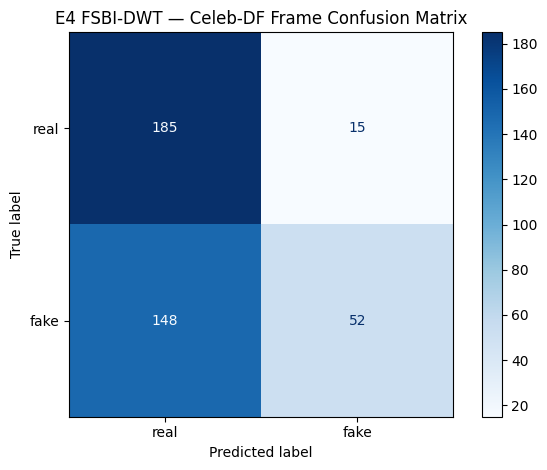

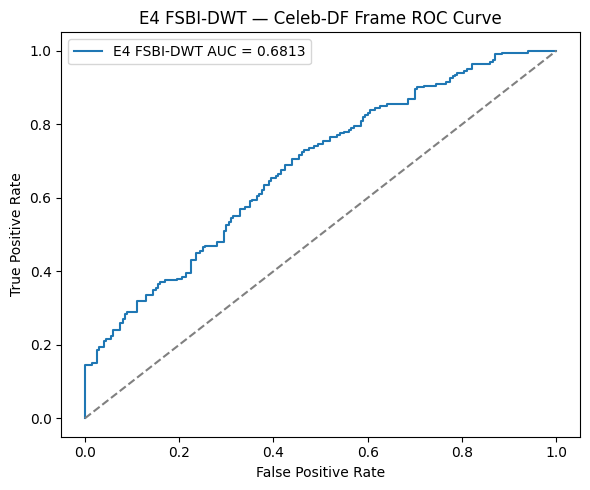

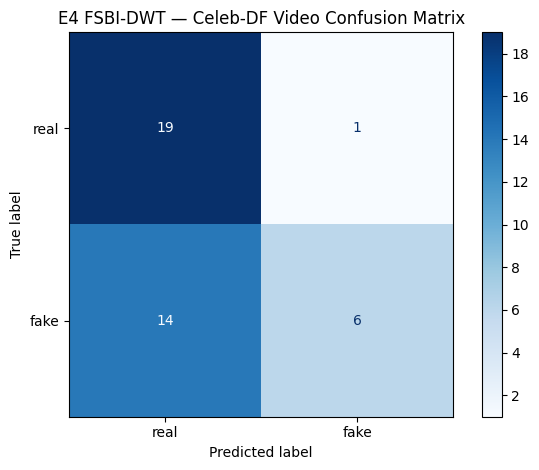

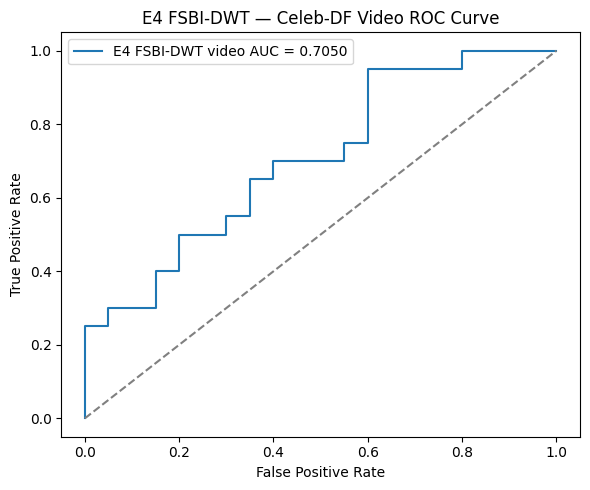

Results saved to: /content/drive/MyDrive/deepfake_project/results/cross_dataset/e4_fsbi_dwt_celebdf_results.json
Confusion matrix saved to: /content/drive/MyDrive/deepfake_project/plots/cross_dataset/e4_fsbi_dwt_celebdf_frame_confusion_matrix.png
ROC curve saved to: /content/drive/MyDrive/deepfake_project/plots/cross_dataset/e4_fsbi_dwt_celebdf_frame_roc_curve.png
Video confusion matrix saved to: /content/drive/MyDrive/deepfake_project/plots/cross_dataset/e4_fsbi_dwt_celebdf_video_confusion_matrix.png
Video ROC curve saved to: /content/drive/MyDrive/deepfake_project/plots/cross_dataset/e4_fsbi_dwt_celebdf_video_roc_curve.png


In [6]:
if RUN_EVALUATION:
    binary_fake_labels = (
        np.asarray(all_labels) == FAKE_INDEX
    ).astype(int)

    accuracy = accuracy_score(all_labels, all_predictions)
    macro_precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    macro_recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    fake_recall = recall_score(
        all_labels,
        all_predictions,
        labels=[FAKE_INDEX],
        average="macro",
        zero_division=0,
    )
    roc_auc = roc_auc_score(
        binary_fake_labels,
        all_fake_probabilities,
    )

    video_records = {}
    for video_id, label, fake_probability in zip(
        all_video_ids,
        all_labels,
        all_fake_probabilities,
    ):
        record = video_records.setdefault(
            video_id,
            {"label": label, "fake_probabilities": []},
        )
        if record["label"] != label:
            raise RuntimeError(
                f"Inconsistent frame labels for source video {video_id}"
            )
        record["fake_probabilities"].append(fake_probability)

    video_ids = sorted(video_records)
    video_labels = [video_records[v]["label"] for v in video_ids]
    video_fake_probabilities = [
        float(np.mean(video_records[v]["fake_probabilities"]))
        for v in video_ids
    ]
    video_predictions = [
        FAKE_INDEX if probability >= DECISION_THRESHOLD else REAL_INDEX
        for probability in video_fake_probabilities
    ]
    binary_video_fake_labels = (
        np.asarray(video_labels) == FAKE_INDEX
    ).astype(int)

    video_accuracy = accuracy_score(video_labels, video_predictions)
    video_macro_precision = precision_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_macro_recall = recall_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_macro_f1 = f1_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_fake_recall = recall_score(
        video_labels,
        video_predictions,
        labels=[FAKE_INDEX],
        average="macro",
        zero_division=0,
    )
    video_roc_auc = roc_auc_score(
        binary_video_fake_labels, video_fake_probabilities
    )

    ordered_labels = [REAL_INDEX, FAKE_INDEX]
    ordered_names = ["real", "fake"]
    matrix = confusion_matrix(
        all_labels,
        all_predictions,
        labels=ordered_labels,
    )
    video_matrix = confusion_matrix(
        video_labels, video_predictions, labels=ordered_labels
    )
    video_report = classification_report(
        video_labels,
        video_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    report = classification_report(
        all_labels,
        all_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    print("=" * 65)
    print("E4 FSBI-DWT — CELEB-DF FRAME-LEVEL RESULTS")
    print("=" * 65)
    print(f"Frames evaluated : {len(all_labels)}")
    print(f"Accuracy         : {accuracy:.2%}")
    print(f"Macro precision  : {macro_precision:.2%}")
    print(f"Macro recall     : {macro_recall:.2%}")
    print(f"Macro F1-score   : {macro_f1:.2%}")
    print(f"Fake recall      : {fake_recall:.2%}")
    print(f"ROC-AUC          : {roc_auc:.4f}")
    print()
    print(classification_report(
        all_labels,
        all_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
    ))
    print("Confusion matrix [real, fake]:")
    print(matrix)

    print()
    print("=" * 65)
    print("E4 FSBI-DWT — CELEB-DF VIDEO-LEVEL RESULTS")
    print("=" * 65)
    print(f"Videos evaluated : {len(video_labels)}")
    print(f"Accuracy         : {video_accuracy:.2%}")
    print(f"Macro precision  : {video_macro_precision:.2%}")
    print(f"Macro recall     : {video_macro_recall:.2%}")
    print(f"Macro F1-score   : {video_macro_f1:.2%}")
    print(f"Fake recall      : {video_fake_recall:.2%}")
    print(f"ROC-AUC          : {video_roc_auc:.4f}")
    print()
    print(classification_report(
        video_labels,
        video_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
    ))
    print("Confusion matrix [real, fake]:")
    print(video_matrix)

    results = {
        "experiment": "E4",
        "evaluation_dataset": "Celeb-DF v2 fixed pilot",
        "evaluation_level": "frame_and_video",
        "training_dataset": "FaceForensics++ clean video-level split",
        "evaluation_type": "cross-dataset without retraining or adaptation",
        "checkpoint": CHECKPOINT_PATH,
        "preprocessing": (
            "Celeb-DF RetinaFace crop with 15% margin; resize 224x224; "
            "scale to [0,1]; official FSBI sym2/reflect DWT approximation "
            "averaged with the source channel; no clipping; no ImageNet normalisation"
        ),
        "frequency_transform": {
            "source": "official FSBI get_dwt_rgb adaptation",
            "wavelet": FSBI_WAVELET,
            "mode": FSBI_MODE,
            "applied_to": "both genuine real and genuine manipulated test crops",
            "clipped_or_renormalised": False,
        },
        "synthetic_sbi_used_during_test": False,
        "class_to_idx": {"real": REAL_INDEX, "fake": FAKE_INDEX},
        "fake_output_index": FAKE_INDEX,
        "decision_threshold": DECISION_THRESHOLD,
        "frames_evaluated": len(all_labels),
        "source_videos_evaluated": len(actual_test_video_ids),
        "external_manifest_path": SPLIT_MANIFEST_PATH,
        "pilot_videos": {"real": 20, "fake": 20},
        "frames_per_video": 10,
        "external_set_used_for_tuning": False,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "fake_recall": fake_recall,
        "roc_auc": roc_auc,
        "confusion_matrix_order": ordered_names,
        "confusion_matrix": matrix.tolist(),
        "classification_report": report,
        "video_level": {
            "aggregation": "mean fake probability across frames",
            "videos_evaluated": len(video_labels),
            "accuracy": video_accuracy,
            "macro_precision": video_macro_precision,
            "macro_recall": video_macro_recall,
            "macro_f1": video_macro_f1,
            "fake_recall": video_fake_recall,
            "roc_auc": video_roc_auc,
            "confusion_matrix_order": ordered_names,
            "confusion_matrix": video_matrix.tolist(),
            "classification_report": video_report,
        },
    }

    os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(CONFUSION_PLOT_PATH), exist_ok=True)

    with open(RESULTS_PATH, "w") as results_file:
        json.dump(results, results_file, indent=4)

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=ordered_names,
    )
    display.plot(cmap="Blues", values_format="d")
    plt.title("E4 FSBI-DWT — Celeb-DF Frame Confusion Matrix")
    plt.tight_layout()
    plt.savefig(CONFUSION_PLOT_PATH, dpi=200)
    plt.show()

    false_positive_rate, true_positive_rate, _ = roc_curve(
        binary_fake_labels,
        all_fake_probabilities,
    )
    plt.figure(figsize=(6, 5))
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"E4 FSBI-DWT AUC = {roc_auc:.4f}",
    )
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("E4 FSBI-DWT — Celeb-DF Frame ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ROC_PLOT_PATH, dpi=200)
    plt.show()

    video_display = ConfusionMatrixDisplay(
        confusion_matrix=video_matrix,
        display_labels=ordered_names,
    )
    video_display.plot(cmap="Blues", values_format="d")
    plt.title("E4 FSBI-DWT — Celeb-DF Video Confusion Matrix")
    plt.tight_layout()
    plt.savefig(VIDEO_CONFUSION_PLOT_PATH, dpi=200)
    plt.show()

    video_fpr, video_tpr, _ = roc_curve(
        binary_video_fake_labels, video_fake_probabilities
    )
    plt.figure(figsize=(6, 5))
    plt.plot(video_fpr, video_tpr, label=f"E4 FSBI-DWT video AUC = {video_roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("E4 FSBI-DWT — Celeb-DF Video ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(VIDEO_ROC_PLOT_PATH, dpi=200)
    plt.show()

    print("Results saved to:", RESULTS_PATH)
    print("Confusion matrix saved to:", CONFUSION_PLOT_PATH)
    print("ROC curve saved to:", ROC_PLOT_PATH)
    print("Video confusion matrix saved to:", VIDEO_CONFUSION_PLOT_PATH)
    print("Video ROC curve saved to:", VIDEO_ROC_PLOT_PATH)

## Interpretation boundary

These results estimate E4 cross-dataset generalisation on a balanced 40-video Celeb-DF pilot. Compare E4 directly with E3b on the identical pilot to test whether the FSBI-DWT extension improved external generalisation. Do not tune the threshold after seeing these labels.

After a successful run, update the **Cross-Dataset Generalisation Results** and **Overall Comparison and Research Findings** tables. Keep the pilot-size limitation explicit.
